In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
!pip install wldhx.yadisk-direct
!curl -L $(yadisk-direct https://disk.yandex.ru/d/vVEOWPFY3NruT7) -o Train_rev1.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100  122M  100  122M    0     0  13.7M      0  0:00:08  0:00:08 --:--:-- 21.6M


In [6]:
!pip install torch

In [12]:
data = pd.read_csv("/content/Train_rev1.zip", compression='zip', index_col=None)
data.shape

(244768, 12)

In [13]:
data.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


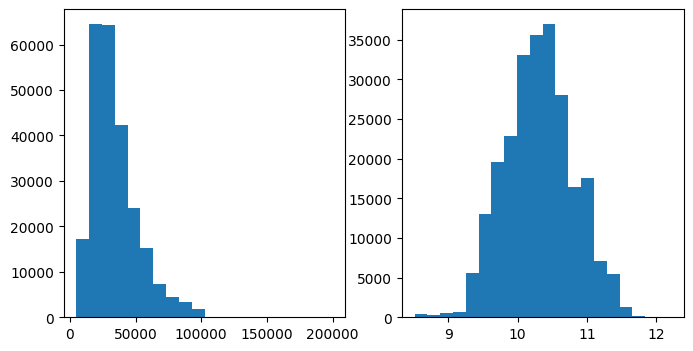

In [14]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.hist(data["SalaryNormalized"], bins=20);

plt.subplot(1, 2, 2)
plt.hist(data['Log1pSalary'], bins=20);

In [15]:
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"

data.sample(3)

# **** in the discription are a direct salary (which should not be mentioned in the input for a model to not cheat)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary
10236,66314557,SKODA SALES EXECUTIVE,Gordon Lamb Limited are a family owned motor g...,Derbyshire,Derbyshire,NaN,NaN,Gordon Lamb Ltd,Retail Jobs,30k pa OTE + Company car,30000,MyUkJobs,10.308986
3583,58869891,Centre Lathe Turner/Supervisor,The works are currently looking for an apprent...,"Bradford, West Yorkshire, England, West Yorkshire",Bradford,NaN,permanent,The Works Uk Ltd,Engineering Jobs,21000 - 21500/annum,21250,cv-library.co.uk,9.964159
128076,70084222,Programme Manager Payments Jobs In Scotland,"Our client, a large financial services client,...",Edinburgh and Lothians,UK,NaN,contract,Head Resourcing Ltd,Healthcare & Nursing Jobs,Up to 800 Per Day,192000,jobsinscotland.com,12.165256


In [16]:
print("Raw text:")
print(data["FullDescription"][1])
print(type(data["FullDescription"][1]))

Raw text:
Stress Engineer Glasgow Salary **** to **** We re currently looking for talented engineers to join our growing Glasgow team at a variety of levels. The roles are ideally suited to high calibre engineering graduates with any level of appropriate experience, so that we can give you the opportunity to use your technical skills to provide high quality input to our aerospace projects, spanning both aerostructures and aeroengines. In return, you can expect good career opportunities and the chance for advancement and personal and professional development, support while you gain Chartership and some opportunities to possibly travel or work in other offices, in or outside of the UK. The Requirements You will need to have a good engineering degree that includes structural analysis (such as aeronautical, mechanical, automotive, civil) with some experience in a professional engineering environment relevant to (but not limited to) the aerospace sector. You will need to demonstrate experie

In [17]:
import nltk

tokenizer = nltk.tokenize.WordPunctTokenizer()

def some_function(sentence: str)->str:
  sentence = str(sentence)
  return ' '.join(tokenizer.tokenize(sentence)).lower()

data["FullDescription"] = data["FullDescription"].apply(some_function)
data["Title"] = data["Title"].apply(some_function)

In [18]:
print("Tokenized:")
print(data["FullDescription"][2::100000])
assert data["FullDescription"][2][:50] == 'mathematical modeller / simulation analyst / opera'
assert data["Title"][54321] == 'international digital account manager ( german )'

Tokenized:
2         mathematical modeller / simulation analyst / o...
100002    a successful and high achieving specialist sch...
200002    web designer html , css , javascript , photosh...
Name: FullDescription, dtype: object


In [19]:
from collections import Counter
token_counts = Counter()

for title in data["Title"].values:
  for token in title.split():
    token_counts[token]+=1
for title in data["FullDescription"].values:
  for token in title.split():
    token_counts[token]+=1


In [20]:
print("Total unique tokens :", len(token_counts))
print('\n'.join(map(str, token_counts.most_common(n=5))))
print('...')
print('\n'.join(map(str, token_counts.most_common()[-3:])))

assert token_counts.most_common(1)[0][1] in  range(2600000, 2700000)
assert len(token_counts) in range(200000, 210000)
print('Correct!')

Total unique tokens : 202704
('and', 2657388)
('.', 2523216)
(',', 2318606)
('the', 2080994)
('to', 2019884)
...
('stephanietraveltraderecruitmnt', 1)
('ruabon', 1)
('lowehays', 1)
Correct!


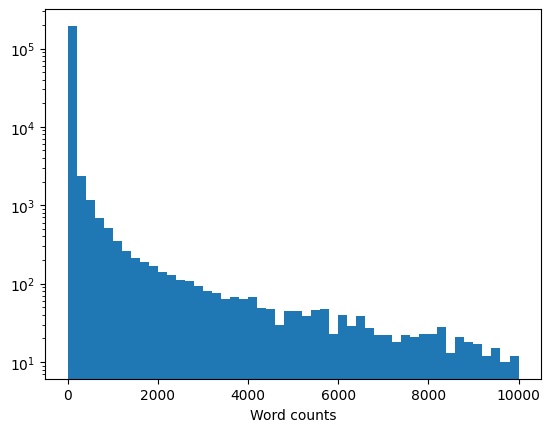

In [21]:
# we should cut of the unnecessary tokens and replace by unknown

plt.hist(list(token_counts.values()), range=[0, 10**4], bins=50, log=True)
plt.xlabel("Word counts");

In [22]:
min_count = 10

# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = sorted(t for t,c in token_counts.items() if c>=min_count)

# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

In [23]:
print("Vocabulary size:", len(tokens))
assert type(tokens) == list
assert len(tokens) in range(32000, 35000)
assert 'me' in tokens
assert UNK in tokens
print("Correct!")

Vocabulary size: 34158
Correct!


In [24]:
#token_to_id = <your code here - dict of token name to its index in tokens>
token_to_id = {}
for idx, tok in enumerate(tokens):
  token_to_id[tok]=idx

In [25]:
assert isinstance(token_to_id, dict)
assert len(token_to_id) == len(tokens)
for tok in tokens:
    assert tokens[token_to_id[tok]] == tok

print("Correct!")

Correct!


In [26]:
UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [27]:
print("Lines:")
print('\n'.join(data["Title"][::100000].values), end='\n\n')
print("Matrix:")
print(as_matrix(data["Title"][::100000]))

Lines:
engineering systems analyst
hr assistant
senior ec & i engineer

Matrix:
[[10807 30161  2166     1     1]
 [15020  2844     1     1     1]
 [27645 10201    16 15215 10804]]


In [28]:
from sklearn.feature_extraction import DictVectorizer

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

In [29]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

Train size =  195814
Validation size =  48954


In [30]:
import torch.nn as nn
import torch.nn.functional as F
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'


def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])

In [31]:
make_batch(data_train[:3], max_len=10)

{'Title': tensor([[27645, 29893, 33674,     1,     1,     1,     1],
         [29239,   197, 19175, 20042, 15554, 23162,  4051],
         [10609, 30412, 17746,    33,  8705, 29157,    65]], device='cuda:0'),
 'FullDescription': tensor([[27645, 29893, 33674, 32939,   982, 27645, 29893, 33674, 16451, 32939],
         [29239,   197, 19175, 20042, 15554, 23162,  4051, 25511,   907,    82],
         [30746, 21956, 20601,  6409, 16451,  8165, 27493,   982, 30412, 17746]],
        device='cuda:0'),
 'Categorical': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'),
 'Log1pSalary': tensor([ 9.7115, 10.4631, 10.7144], device='cuda:0')}

In [44]:
# THE MAIN MODEL
class SalaryPredictor(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64,
        emb_dim = 300, # embedings dimention is 300 as FastText size is 300 (for use to be able to use pretrained embeddings)

        kernel_sizes = [3, 5, 7],
        conv_filters = (16,32,64),

        cat_hidden=64,
        fc_hidden=128,

        padding_idx = 1,

        dropout = 0.3):
        super().__init__()

        # embeddings for tokens
        self.token_emb = nn.Embedding(n_tokens, emb_dim, padding_idx=padding_idx)

        # convs Tite
        self.title_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_channels=emb_dim, out_channels=f, kernel_size=k, stride=idx+1, padding=k//2),
                nn.BatchNorm1d(f),   # добавили BN
                nn.ReLU()
            )
            for idx, (f, k) in enumerate(zip(conv_filters, kernel_sizes))
        ])
        # convs FullDescription
        self.desc_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_channels=emb_dim, out_channels=f, kernel_size=k, stride=idx+1, padding=k//2),
                nn.BatchNorm1d(f),
                nn.ReLU()
            )
            for idx, (f, k) in enumerate(zip(conv_filters, kernel_sizes))
        ])

        text_feat_size = sum(conv_filters)

        # categories for the company name
        self.cat_proj = nn.Sequential(
            nn.Linear(n_cat_features, cat_hidden),
            nn.BatchNorm1d(cat_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        concat_size = text_feat_size + text_feat_size + cat_hidden

        self.fc = nn.Sequential(
            nn.Linear(concat_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, 1)
        )

    def _encode_text(self, token_ids, convs):
      x = self.token_emb(token_ids)     # (B, L, E)
      x = x.permute(0, 2, 1)            # (B, E, L)

      pooled = []
      for conv in convs:
          c = conv(x)   # (B, out_ch, L) Conv + BN + ReLU
          # max pool can overlook important info but attention is too complicated so I decided to stick with avg (balance of activation and information perservance)
          # avg pooling is better for the long context like full discription
          p = F.adaptive_avg_pool1d(c, 1).squeeze(-1)
          pooled.append(p)
      return torch.cat(pooled, dim=1)

    def forward(self, batch):
        title_ids = batch['Title']                 # (B, L_title)
        desc_ids  = batch['FullDescription']       # (B, L_desc)
        cats      = batch['Categorical']           # (B, n_cat_features)

        title_feat = self._encode_text(title_ids, self.title_convs)   # (B, text_feat)
        desc_feat  = self._encode_text(desc_ids,  self.desc_convs)    # (B, text_feat)
        cat_feat   = self.cat_proj(cats)                               # (B, cat_hidden)

        h = torch.cat([title_feat, desc_feat, cat_feat], dim=1)        # (B, concat)
        out = self.fc(h).squeeze(-1)                                  # (B,)
        return out

In [45]:
model = SalaryPredictor()

In [26]:
# to load pretrained embeddings
!wget -c https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz

--2025-09-01 14:23:02--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 18.154.144.87, 18.154.144.74, 18.154.144.102, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|18.154.144.87|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1325960915 (1.2G) [binary/octet-stream]
Saving to: ‘cc.en.300.vec.gz’

cc.en.300.vec.gz    100%[===================>]   1.23G  55.3MB/s    in 18s     

2025-09-01 14:23:21 (69.5 MB/s) - ‘cc.en.300.vec.gz’ saved [1325960915/1325960915]



In [27]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 15.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 re

In [2]:
from gensim.models import KeyedVectors
wv = KeyedVectors.load_word2vec_format("/content/cc.en.300.vec.gz", binary=False)

In [46]:
import numpy as np
import torch

# adding embeddings (pretrained from FastText)
# unknown words will be initialized randomly
# I will not freze embeddings for them to learn specific meanings from the text (not only general pretraining)

n_tokens = len(tokens)
emb_dim = model.token_emb.embedding_dim

rng = np.random.RandomState(12345)
embedding_matrix = rng.normal(scale=0.01, size=(n_tokens, emb_dim)).astype(np.float32)

for idx, word in enumerate(tokens):
    if word in wv:
        vec = wv[word]
        if vec.shape[0] != emb_dim:
            raise ValueError(f"Dim mismatch for {word}: {vec.shape[0]} vs {emb_dim}")
        embedding_matrix[idx] = vec
model.token_emb.weight.data.copy_(torch.from_numpy(embedding_matrix))

model.to(device)

SalaryPredictor(
  (token_emb): Embedding(34158, 300, padding_idx=1)
  (title_convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(300, 16, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv1d(300, 32, kernel_size=(5,), stride=(2,), padding=(2,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): Conv1d(300, 64, kernel_size=(7,), stride=(3,), padding=(3,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (desc_convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(300, 16, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv1d

In [35]:
batch = make_batch(data_train[:100], device=device)
criterion = nn.MSELoss()

dummy_pred = model(batch)
dummy_loss = criterion(dummy_pred, batch[TARGET_COLUMN])
assert dummy_pred.shape == torch.Size([100])
assert len(torch.unique(dummy_pred)) > 20, "model returns suspiciously few unique outputs. Check your initialization"
assert dummy_loss.ndim == 0 and 0. <= dummy_loss <= 250., "make sure you minimize MSE"

In [36]:
def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """ iterates minibatches of data in random order """
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)

        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start : start + batch_size]], device=device, **kwargs)
            yield batch

        if not cycle: break

In [37]:
from tqdm.auto import tqdm

BATCH_SIZE = 64
EPOCHS = 5

In [38]:
def print_metrics(model, data, batch_size=BATCH_SIZE, name="", device=torch.device('cpu'), **kw):
    squared_error = abs_error = num_samples = 0.0
    model.eval()
    with torch.no_grad():
        for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
            batch_pred = model(batch)
            squared_error += torch.sum(torch.square(batch_pred - batch[TARGET_COLUMN]))
            abs_error += torch.sum(torch.abs(batch_pred - batch[TARGET_COLUMN]))
            num_samples += len(batch_pred)
    mse = squared_error.detach().cpu().numpy() / num_samples
    mae = abs_error.detach().cpu().numpy() / num_samples
    print("%s results:" % (name or ""))
    print("Mean square error: %.5f" % mse)
    print("Mean absolute error: %.5f" % mae)
    return mse, mae

In [47]:
criterion = nn.MSELoss(reduction='sum')
# moderate learning rate of 1e-4 (can be 1e-3 but as we do not want to lose embeddings I will stich with -4)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print_metrics(model, data_val, device=device)


# without a
# 1) batch norm
# 2) avg pooling
# 3) pretrained embeddings
# the mean sq error and abs error were: 0.09 and 0.22 respectively but now they are 0.07 and 0.2
# not a perfect result but it improved!

epoch: 0


  0%|          | 0/3059 [00:00<?, ?it/s]

 results:
Mean square error: 0.12371
Mean absolute error: 0.26979
epoch: 1


  0%|          | 0/3059 [00:00<?, ?it/s]

 results:
Mean square error: 0.10093
Mean absolute error: 0.24109
epoch: 2


...

 results:
Mean square error: 0.09387
Mean absolute error: 0.22921
epoch: 3


  0%|          | 0/3059 [00:00<?, ?it/s]

 results:
Mean square error: 0.08674
Mean absolute error: 0.21976
epoch: 4


  0%|          | 0/3059 [00:00<?, ?it/s]

 results:
Mean square error: 0.07918
Mean absolute error: 0.20970


In [48]:
def explain(model, sample, col_name='Title'):
    """ Computes the effect each word had on model predictions """
    sample = dict(sample)
    sample_col_tokens = [tokens[token_to_id.get(tok, 0)] for tok in sample[col_name].split()]
    data_drop_one_token = pd.DataFrame([sample] * (len(sample_col_tokens) + 1))

    for drop_i in range(len(sample_col_tokens)):
        data_drop_one_token.loc[drop_i, col_name] = ' '.join(UNK if i == drop_i else tok
                                                   for i, tok in enumerate(sample_col_tokens))

    *predictions_drop_one_token, baseline_pred = model(make_batch(data_drop_one_token, device=device)).detach().cpu()
    diffs = baseline_pred - torch.Tensor(predictions_drop_one_token)
    return list(zip(sample_col_tokens, diffs))

In [49]:
from IPython.display import HTML, display_html


def draw_html(tokens_and_weights, cmap=plt.get_cmap("bwr"), display=True,
              token_template="""<span style="background-color: {color_hex}">{token}</span>""",
              font_style="font-size:14px;"
             ):

    def get_color_hex(weight):
        rgba = cmap(1. / (1 + np.exp(float(weight))), bytes=True)
        return '#%02X%02X%02X' % rgba[:3]

    tokens_html = [
        token_template.format(token=token, color_hex=get_color_hex(weight))
        for token, weight in tokens_and_weights
    ]


    raw_html = """<p style="{}">{}</p>""".format(font_style, ' '.join(tokens_html))
    if display:
        display_html(HTML(raw_html))

    return raw_html

In [54]:
i = 36605
tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
# normalization as all tokens (except few) were white
max_w = max(abs(w) for _, w in tokens_and_weights) or 1
tokens_and_weights = [(tok, w / max_w) for tok, w in tokens_and_weights]
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);



sales specialist iv access and infusion

sales representative medical sales iv access and infusion an opportunity to work for the industry leading manufacturer of iv access and infusion solutions . formally recognised as the number **** company in this market space , our client are an ethical and dynamic organisation absolutely committed to the advancement of innovative technologies . job title : sales specialist iv access and infusion selling : medication delivery solutions selling to : iv teams , infection control , lead intensive care nurse specialists , ward managers territory : east midlands location : east midlands package : basic : **** k **** k , uncapped bonus in addition , full corporate benefits company information hugely ethical and professional global organisation extremely well established in the uk the market leader across all of their core business areas focus on providing cutting edge solutions along with outstanding service and support a business that retain talented personnel by offering a strong platform for career development sales specialist iv access and infusion you must have / be the following at least 2 years medical device sales experience . candidates who have sold disposables / consumables or similar into hospitals would be of particular interest . candidates must have sold into hospitals demonstrable performance and achievements so far personable , adaptable and willing to learn keen and eager to be a success candidates must have a degree or at least be able to show a strong ability to learn role information managing the east midlands region selling across the company ' s range of iv and infusion solutions portfolio selling into lead intensive care nurse specialists , ward managers , iv teams , infection control teams , procurement sales specialist iv access and infusion candidates must be eligible to work and live in the uk . please contact allan waller on **** **** **** or please hit the apply button . this job was originally posted as www . salestarget . co . uk / jobseeking / UNK ****

In [55]:

i = 12077
tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
max_w = max(abs(w) for _, w in tokens_and_weights) or 1
tokens_and_weights = [(tok, w / max_w) for tok, w in tokens_and_weights]
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

cleaning operative

12 . 5 hours per week monday friday 9am 11 . 30am duties to include sweeping , mopping , vacuuming , buffing , cleaning staff toilets and rest room . must be able to read as they will be using UNK which need UNK as per instructions on the containers . sucessfull applicants will be trained on all electrical appliances and UNK of cleaning materials .

In [56]:
i = np.random.randint(len(data))
print("Index:", i)
print("Salary (gbp):", np.expm1(model(make_batch(data.iloc[i: i+1], device=device)).detach().cpu()))

tokens_and_weights = explain(model, data.loc[i], "Title")
max_w = max(abs(w) for _, w in tokens_and_weights) or 1
tokens_and_weights = [(tok, w / max_w) for tok, w in tokens_and_weights]
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
max_w = max(abs(w) for _, w in tokens_and_weights) or 1
tokens_and_weights = [(tok, w / max_w) for tok, w in tokens_and_weights]
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

Index: 86983
Salary (gbp): tensor([44492.3242])


allied health care professional : optometrist jobs in ashford

flame health optometry jobs optometrist jobs in ashford flame health optometry are looking to recruit an optometrist in ashford . although the practice is based in kent , it is a **** minute train journey from UNK cross train station . there has never been a better time to join a company that can provide a solid career structure as well as an unbeatable support system to help you achieve your career aims . our client puts their clinicians at the heart of the business . to ensure that they stay at the forefront of the industry and to help you develop , they make sure you ' ll be given opportunities beyond holding clinics such as supervising preregistration students , working in community schemes or managing practices . this company can provide a wide variety of career choices in a huge range of working environments and every practice meets the needs of people from every walk of life . put simply , there ' s a range of practices to suit all optics professionals . whether you are looking to work primarily in a single location , across a number of practices or as one of their growing band of professional managers . as an optometrist you must be able to combine a real professional interest in your field with a passion for providing exceptional standards of service . this will give you the opportunity to really drive the business from the consulting room . your clinical excellence will fuel the companies ' success . the company has key development programmes because they are interested in whom you are , and they want to support you to be the best you can . so every effort will be made to ensure that you have every opportunity to explore your potential , and realise it . in return for your hard work and enthusiasm , the company will reward you with a package that is one of the best and most comprehensive in the uk . as well as a competitive salary , other options include flexible fulltime , part time or taking on a franchise of your own . optometry benefits : excellent salary package which can include relocation and location supplements for the right candidate up to 29 days holiday plus bank holidays excellent bonus designed to reward levels of customer care sales and company profits staff discount card offering generous savings of up to 22 . 5 % free eye test and save a massive 70 % on **** pairs of glasses per year reimburse all of the general optical council ' s fees for retention of registration and college fees for prereg supervisors flexible and affordable pension arrangement to employees . of course you will be a qualified and goc registered optometrist to apply for this job or enquire about additional optometrist opportunities in ashford or the kent area contact flame health freephone on **** **** **** or from a mobile on **** **** alternatively email optometryflamehealth . com flame health associates llp operates as an employment agency & employment business